In [36]:
import requests
import pandas as pd
import time
from tqdm import tqdm
import re
import spacy
import numpy as np
from spacy.matcher import PhraseMatcher

## Data Acquisition

In [2]:
API_KEY = "84287db0-182f-4d1b-9d8e-3c2047664fe4"

In [3]:
BASE_URL = "https://content.guardianapis.com/search"

params = {
    "api-key": API_KEY,
    "section": "business",
    "from-date": "2019-01-01",
    "to-date": "2024-12-31",
    "show-fields": "bodyText,headline,byline",
    "show-tags": "type,keyword,tone",
    "page-size": 50,   # maximum allowed
    "page": 1
}

In [4]:
response = requests.get(BASE_URL, params=params)

print("Status code:", response.status_code)
print(response.url)

data = response.json()

Status code: 200
https://content.guardianapis.com/search?api-key=84287db0-182f-4d1b-9d8e-3c2047664fe4&section=business&from-date=2019-01-01&to-date=2024-12-31&show-fields=bodyText%2Cheadline%2Cbyline&show-tags=type%2Ckeyword%2Ctone&page-size=50&page=1


In [5]:
all_articles = []

# First request to get total pages
response = requests.get(BASE_URL, params=params)
data = response.json()

total_pages = data["response"]["pages"]
print(f"Total pages in 2019-2024 in business section: {total_pages}")

for page in tqdm(range(1, total_pages + 1)):
    params["page"] = page
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    articles = data["response"]["results"]
    
    for article in articles:
        fields = article.get("fields", {})
        
        all_articles.append({
            "webTitle": article.get("webTitle"),
            "sectionName": article.get("sectionName"),
            "webPublicationDate": article.get("webPublicationDate"),
            "headline": fields.get("headline"),
            "byline": fields.get("byline"),
            "bodyText": fields.get("bodyText"),
            "tags": article.get("tags"),
            "webUrl": article.get("webUrl")
        })
    
    time.sleep(1)

Total pages in 2019-2024 in business section: 461


100%|████████████████████████████████████████████████████████████████████████████████| 461/461 [09:46<00:00,  1.27s/it]


In [49]:
df = pd.DataFrame(all_articles)

print("Total articles pulled:", len(df))

Total articles pulled: 23027


In [50]:
df.head()

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
0,Great Guinness heist: thieves stole truck carr...,Business,2024-12-31T18:18:27Z,Great Guinness heist: thieves stole truck carr...,Rob Davies and Helena Horton,"In the days leading up to Christmas, stout-lov...","[{'id': 'business/hospitality-industry', 'type...",https://www.theguardian.com/business/2024/dec/...
1,FTSE 100 rallies by 5.7% in 2024 in ‘a year of...,Business,2024-12-31T16:25:35Z,FTSE 100 rallies by 5.7% in 2024 in ‘a year of...,Graeme Wearden,A late PS: The three major U.S. stock indices ...,"[{'id': 'business/business', 'type': 'keyword'...",https://www.theguardian.com/business/live/2024...
2,Russia winds down gas supply to Europe via Ukr...,Business,2024-12-31T15:18:52Z,Russia winds down gas supply to Europe via Ukr...,Jillian Ambrose Energy correspondent,Europe will receive the last Russian gas sent ...,"[{'id': 'business/gas', 'type': 'keyword', 'se...",https://www.theguardian.com/business/2024/dec/...
3,FTSE records strongest annual gain since 2021 ...,Business,2024-12-31T15:16:25Z,FTSE records strongest annual gain since 2021 ...,Graeme Wearden,The UK’s blue-chip stock index has recorded it...,"[{'id': 'business/ftse', 'type': 'keyword', 's...",https://www.theguardian.com/business/2024/dec/...
4,Green light: the boss of GB Railfreight with a...,Business,2024-12-31T13:00:46Z,Green light: the boss of GB Railfreight with a...,Jack Simpson,"Travel north on the east coast mainline, the m...","[{'id': 'business/rail-industry', 'type': 'key...",https://www.theguardian.com/business/2024/dec/...


In [51]:
row = df.iloc[0]

for col in df.columns:
    print(f"{col}: {row[col]}")

webTitle: FTSE 100 rallies by 5.7% in 2024 in ‘a year of resilience’ for the stock market – as it happened
sectionName: Business
webPublicationDate: 2024-12-31T16:25:35Z
headline: FTSE 100 rallies by 5.7% in 2024 in ‘a year of resilience’ for the stock market – as it happened
byline: Graeme Wearden
bodyText: A late PS: The three major U.S. stock indices closed in negative territory tonight. The S&amp;P 500 lost 25 points, or 0.4%, to end at 5,881 points, while the Nasdaq Composite fell by 0.90%. For 2024, the Nasdaq surged nearly 30%, while the bellwether S&amp;P 500 notched more than a 23% gain, marking the index’s best two-year run since 1997-1998. The Dow Jones Industrial Average dipped slightly, to finish at 42,544.22 points, meaning it gained almost 13% during the year. Time to wrap up, for the last time this year. The UK’s blue-chip stock index has recorded its strongest annual gain since 2021, despite lagging behind Wall Street over the past year. The FTSE 100 index, which track

## Exploratory Data Analysis (EDA)

In [9]:
df.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
count,23027,23027,23027,23027,22871,23027,23027,23027
unique,23011,1,22596,23011,2176,23023,22113,23027
top,UK inflation: which goods and services have ch...,Business,2019-06-26T16:00:19Z,UK inflation: which goods and services have ch...,Sarah Butler,,"[{'id': 'business/retail', 'type': 'keyword', ...",https://www.theguardian.com/business/2019/jan/...
freq,9,23027,5,9,1416,5,48,1


In [10]:
print("Total Authors:", df["byline"].nunique())

Total Authors: 2176


In [11]:
print("Most Frequent Authors")
print(df["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Sarah Butler                                  1416
Jasper Jolly                                  1235
Graeme Wearden                                1116
Julia Kollewe                                  984
Nils Pratley                                   915
Phillip Inman                                  846
Mark Sweney                                    845
Richard Partington Economics correspondent     785
Kalyeena Makortoff Banking correspondent       658
Rob Davies                                     621
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Zoe Wood City reporter                                 1
Sarah Boseley and Rob Davies                           1
Larry Elliott, Richard Partington and Jasper Jolly     1
Sarah Butler and Press Association                     1
Sam Levin in Windsor, California                       1
Hannah Ellis-Petersen South east Asia correspondent    1
Katharine Murphy and Lisa Cox                  

In [12]:
len(df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts())

1261

In [13]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().head(5)

byline
Guardian staff and agencies                            56
Elias Visontay Transport and urban affairs reporter    52
Jasper Jolly and agencies                              38
Guardian staff and agency                              30
Staff and agencies                                     26
Name: count, dtype: int64

In [14]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().tail(5)

byline
Jasper Jolly and Justin McCurry in Tokyo    1
Sarah Butler and Angela Monaghan            1
Dominic Rushe and Phillip Inman             1
Sarah Boseley and Rob Davies                1
Joanna Partridge  and Gwyn Topham           1
Name: count, dtype: int64

In [15]:
df["byline"].isna().sum()

np.int64(156)

In [16]:
(df["byline"] == "").sum()

np.int64(76)

In [17]:
df["year"] = pd.to_datetime(df["webPublicationDate"]).dt.year

author_by_year = df.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    484
2020    545
2021    554
2022    626
2023    594
2024    555
Name: byline, dtype: int64


In [18]:
df.groupby("year").size()

year
2019    3606
2020    4244
2021    3989
2022    4070
2023    3655
2024    3463
dtype: int64

In [19]:
df.to_csv("guardian_business_raw.csv", index=False)

# DATA CLEANING

In [20]:
## PARAMETERS
author_min_freq = int(0.001 * len(df)) # Approximately holds atleast 1% of the sample

In [21]:
def clean_authors(df, min_freq=5):
    df = df.copy()
    
    # Remove nulls
    df = df[df["byline"].notna()]
    
    # Remove empty or whitespace-only strings
    df = df[df["byline"].str.strip() != ""]
    
    # Compute author frequencies
    author_counts = df["byline"].value_counts()
    
    # Keep only authors with freq >= min_freq
    valid_authors = author_counts[author_counts >= min_freq].index
    
    df = df[df["byline"].isin(valid_authors)]
    
    return df

In [22]:
df_clean = clean_authors(df, author_min_freq)

print("Before:", len(df))
print("After:", len(df_clean))

Before: 23027
After: 18149


In [23]:
print("Most Frequent Authors")
print(df_clean["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df_clean["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Sarah Butler                                  1416
Jasper Jolly                                  1235
Graeme Wearden                                1116
Julia Kollewe                                  984
Nils Pratley                                   915
Phillip Inman                                  846
Mark Sweney                                    845
Richard Partington Economics correspondent     785
Kalyeena Makortoff Banking correspondent       658
Rob Davies                                     621
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Helena Horton Environment reporter           26
Staff and agencies                           26
Katharine Murphy Political editor            26
Jonathan Barrett Senior business reporter    26
Amy Remeikis                                 26
Lauren Aratani in New York                   25
Jedidajah Otte                               25
Robert Booth Social affairs correspondent    24
Naama

In [24]:
df_clean["year"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.year

author_by_year = df_clean.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    55
2020    59
2021    60
2022    64
2023    70
2024    64
Name: byline, dtype: int64


In [25]:
df_clean.groupby("year").size()

year
2019    2873
2020    3397
2021    3188
2022    3184
2023    2864
2024    2643
dtype: int64

In [26]:
clean_counts = df_clean.groupby("year").size()
raw_counts = df.groupby("year").size()

difference = raw_counts - clean_counts
print(difference)

year
2019    733
2020    847
2021    801
2022    886
2023    791
2024    820
dtype: int64


In [27]:
df_clean["month"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.month
df_clean["day"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.day
df_clean["date"] = pd.to_datetime(df_clean["webPublicationDate"]).dt.tz_localize(None)
df_clean["tm"] = (
    (df_clean["date"] - pd.Timestamp("2019-01-01"))
    .dt.days / 30
)

In [28]:
df_clean["post"] = (df_clean["date"] >= "2022-11-01").astype(int)

In [29]:
df_clean.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl,year,month,day,date,tm,post
count,18149,18149,18149,18149,18149,18149,18149,18149,18149.000000,18149.000000,18149.000000,18149,18149.000000,18149.000000
unique,18136,1,17880,18136,79,18149,17389,18149,NaN,NaN,NaN,NaN,NaN,NaN
top,UK inflation: which goods and services have ch...,Business,2019-06-26T16:00:19Z,UK inflation: which goods and services have ch...,Sarah Butler,Britain’s biggest listed companies will be for...,"[{'id': 'business/retail', 'type': 'keyword', ...",https://www.theguardian.com/business/2019/jan/...,NaN,NaN,NaN,NaN,NaN,NaN
freq,8,18149,4,8,1416,1,44,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.424156,6.467905,15.621026,2021-12-02 10:38:48.601355520,35.529296,0.330982
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,1.000000,1.000000,2019-01-01 00:01:06,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,3.000000,8.000000,2020-06-22 14:39:17,17.933333,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.000000,6.000000,16.000000,2021-11-18 15:24:50,35.066667,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,9.000000,23.000000,2023-04-25 14:34:03,52.500000,1.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,12.000000,31.000000,2024-12-31 16:25:35,73.033333,1.000000


In [30]:
row = df_clean.iloc[0]

for col in df_clean.columns:
    print(f"{col}: {row[col]}")

webTitle: FTSE 100 rallies by 5.7% in 2024 in ‘a year of resilience’ for the stock market – as it happened
sectionName: Business
webPublicationDate: 2024-12-31T16:25:35Z
headline: FTSE 100 rallies by 5.7% in 2024 in ‘a year of resilience’ for the stock market – as it happened
byline: Graeme Wearden
bodyText: A late PS: The three major U.S. stock indices closed in negative territory tonight. The S&amp;P 500 lost 25 points, or 0.4%, to end at 5,881 points, while the Nasdaq Composite fell by 0.90%. For 2024, the Nasdaq surged nearly 30%, while the bellwether S&amp;P 500 notched more than a 23% gain, marking the index’s best two-year run since 1997-1998. The Dow Jones Industrial Average dipped slightly, to finish at 42,544.22 points, meaning it gained almost 13% during the year. Time to wrap up, for the last time this year. The UK’s blue-chip stock index has recorded its strongest annual gain since 2021, despite lagging behind Wall Street over the past year. The FTSE 100 index, which track

In [31]:
df_clean.to_csv("guardian_business_clean.csv", index=False)

## DATA PREPROCESSING

In [32]:
df_clean = pd.read_csv("guardian_business_clean.csv")
# Restore datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

In [33]:
def clean_text(text):
    if pd.isna(text):
        return None
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    # Fix HTML entities like &amp;
    text = text.replace("&amp;", "&")
    
    return text.strip()

df_clean["clean_text"] = df_clean["bodyText"].apply(clean_text)

In [34]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

docs = list(nlp.pipe(df_clean["clean_text"], batch_size=50))

In [41]:
HEDGE_TOKENS = {
    "may","might","could","would","should","can",
    "likely","unlikely","possibly","perhaps","potentially","apparently","arguably",
    "seem","seems","seemed","seeming",
    "appear","appears","appeared","appearing",
    "suggest","suggests","suggested","suggesting",
    "estimate","estimates","estimated","estimating",
    "indicate","indicates","indicated","indicating",
    "roughly","about","around","approximately"
}

In [42]:
hedge_counts = []
n_sentences = []
word_counts = []
avg_sentence_lengths = []
burstiness_scores = []

for doc in docs:
    
    sentences = list(doc.sents)
    sentence_lengths = []
    hedge_count = 0
    
    for sent in sentences:
        length = 0
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            
            length += 1
            
            # Hedge detection using lemma (cleaner than raw text)
            if token.lemma_.lower() in HEDGE_TOKENS:
                hedge_count += 1
        
        sentence_lengths.append(length)
    
    n_sent = len(sentence_lengths)
    total_words = sum(sentence_lengths)
    
    n_sentences.append(n_sent)
    word_counts.append(total_words)
    hedge_counts.append(hedge_count)
    
    if n_sent > 0:
        avg_len = total_words / n_sent
        avg_sentence_lengths.append(avg_len)
        
        if avg_len > 0:
            burstiness_scores.append(np.std(sentence_lengths) / avg_len)
        else:
            burstiness_scores.append(np.nan)
    else:
        avg_sentence_lengths.append(np.nan)
        burstiness_scores.append(np.nan)

In [43]:
df_clean["n_sentences"] = n_sentences
df_clean["word_count"] = word_counts
df_clean["avg_sentence_length"] = avg_sentence_lengths
df_clean["burstiness"] = burstiness_scores
df_clean["hedge_count"] = hedge_counts
df_clean["hedge_rate"] = df_clean["hedge_count"] / df_clean["word_count"]

In [44]:
df_clean[[
    "word_count",
    "n_sentences",
    "avg_sentence_length",
    "burstiness"
]].describe()

,word_count,n_sentences,avg_sentence_length,burstiness
count,18149.000000,18149.000000,18149.000000,18149.000000
mean,998.881426,40.188716,25.975939,0.422497
std,1346.848680,55.392807,4.182643,0.107494
min,58.000000,2.000000,9.125000,0.091390
25%,475.000000,18.000000,23.370787,0.348847
50%,623.000000,23.000000,25.838710,0.414700
75%,804.000000,34.000000,28.520000,0.482954
max,11784.000000,523.000000,97.800000,1.759458


<Axes: xlabel='year,month'>

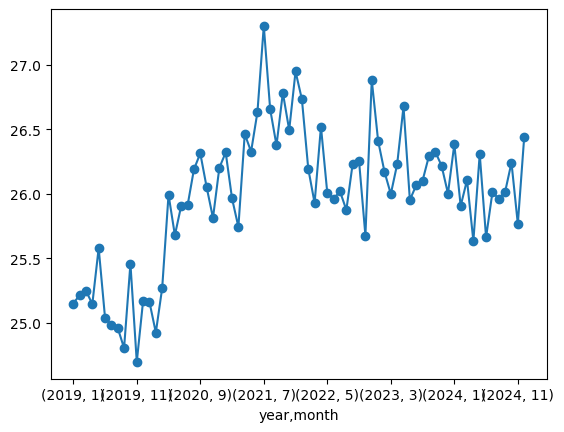

In [45]:
df_clean.groupby(["year", "month"])["avg_sentence_length"].mean().plot(marker="o")

<Axes: xlabel='year,month'>

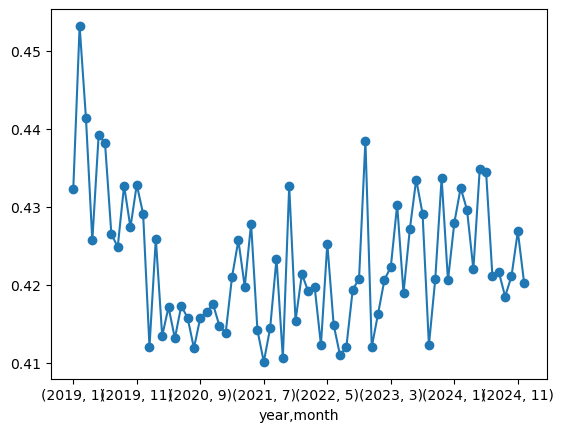

In [46]:
df_clean.groupby(["year", "month"])["burstiness"].mean().plot(marker="o")

<Axes: xlabel='year'>

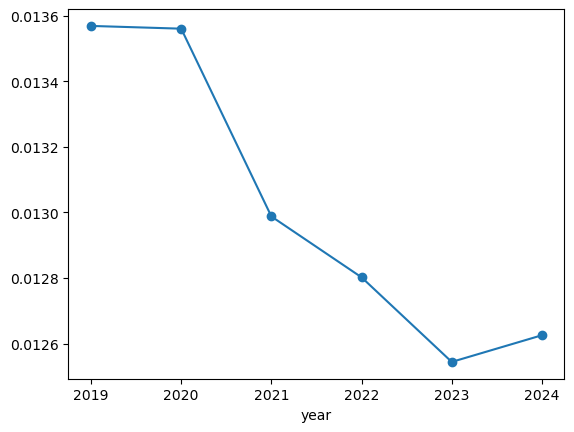

In [47]:
df_clean.groupby("year")["hedge_rate"].mean().plot(marker="o")

In [48]:
df_clean.to_csv("post_processing.csv", index=False)